In [ ]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, confusion_matrix
from xgboost import XGBClassifier

In [4]:
# using SMOTE(Synthetic Minority Over-Sampling Technique) to generate artificial data points, finding nearest neighbours
# SMOTE is only applied to train data
from imblearn.over_sampling import SMOTE

The data is pre-processed as the sensitive data has been transformed using Principal Component Analysis into 
different feature(V1, v2, etc)

In [50]:
df = pd.read_csv("./data/creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Class column is the target variable labelling the transactions as fraud(1) or genuine(0)
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [51]:
y = df['Class']
x = df.drop('Class', axis = 1) # axis = 1 -> application to columns
# class is target variable

In [ ]:
# stratify = y -> to ensure ratio of fraud to genuine transactions remains identical in both train and test

In [63]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size = 0.2,
    random_state= 42,
    # stratify = y
)

SMOTE APPROACH :-

In [45]:
smote = SMOTE()
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [46]:
smote_data_model = RandomForestClassifier(n_jobs=-1)
smote_data_model.fit(x_train_resampled, y_train_resampled)

y_predict = smote_data_model.predict(x_test)
y_prob = smote_data_model.predict_proba(x_test)[:,1]


In [ ]:
# predict -> returns direct classification output
# predict_proba -> returns array of probabilities for all classes

In [47]:
print(classification_report(y_test, y_predict))
print(f"Area Under Precision-Recall Curve (AUPRC): {average_precision_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Area Under Precision-Recall Curve (AUPRC): 0.8678


In [13]:
precision, recalls, thresholds = precision_recall_curve(y_test, y_prob)

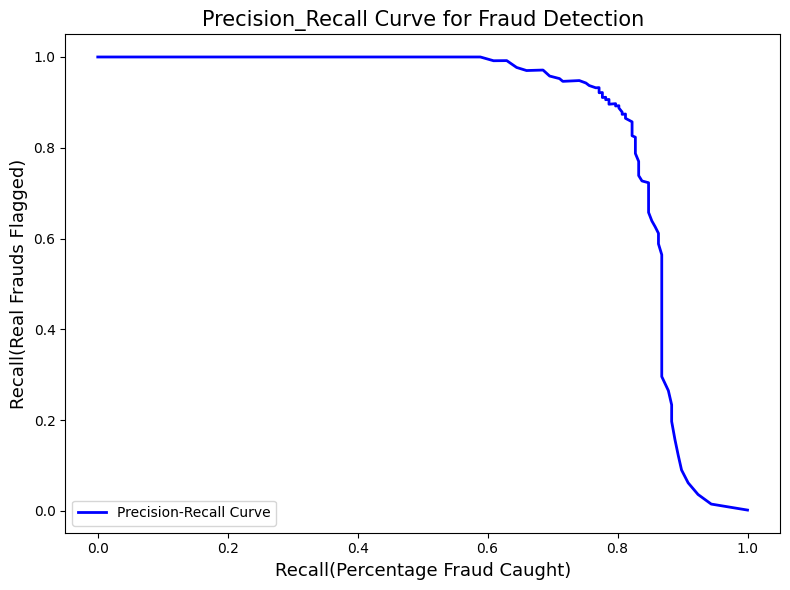

In [14]:
plt.figure(figsize = (8, 6))
plt.plot(recalls, precision, 
         label = 'Precision-Recall Curve', 
         color = 'blue',
         linewidth = 2
         )

plt.title("Precision_Recall Curve for Fraud Detection", fontsize = 15)
plt.xlabel("Recall(Percentage Fraud Caught)", fontsize = 13)
plt.ylabel("Recall(Real Frauds Flagged)", fontsize = 13)
plt.legend(loc = 'lower left')

plt.tight_layout()
plt.show()

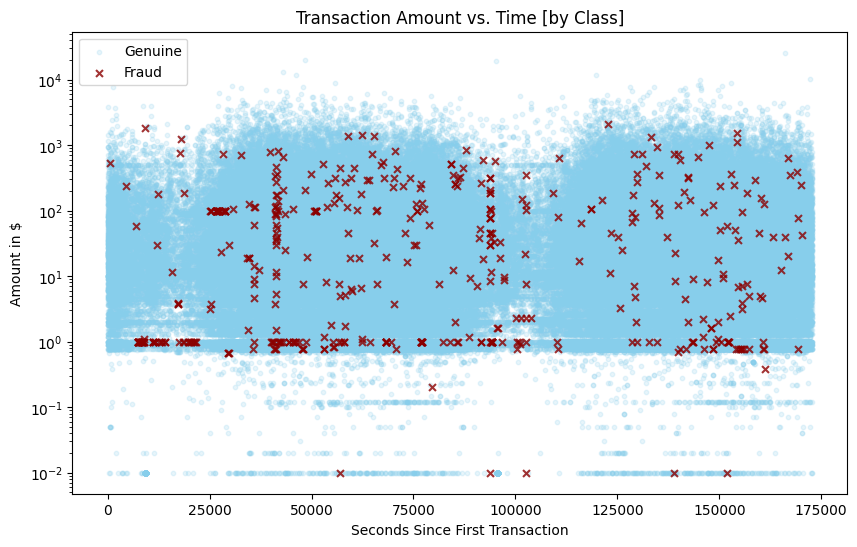

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'], 
            alpha=0.2,
            label='Genuine',
            color='skyblue',
            s=10)

plt.scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'], 
            alpha=0.8,
            label='Fraud',
            color='darkred',
            s=25,
            marker='x')

plt.title('Transaction Amount vs. Time [by Class]')
plt.xlabel('Seconds Since First Transaction')
plt.ylabel('Amount in $')
plt.legend()
plt.yscale('log')
plt.show()


XGB CLASSIFIER :-

In [29]:
ratio = (y_train == 0).sum() 

model_xgb = XGBClassifier(scale_pos_weight = ratio, random_state = 42)
model_xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
y_xgb_pred = model_xgb.predict(x_test)
y_xgb_probs = model_xgb.predict_proba(x_test)[:, 1]

In [39]:
print(classification_report(y_test, y_xgb_pred))
print(f"XGBoost AUPRC: {average_precision_score(y_test, y_xgb_probs):.4f}\n")


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    113726
           1       0.86      0.80      0.83       197

    accuracy                           1.00    113923
   macro avg       0.93      0.90      0.92    113923
weighted avg       1.00      1.00      1.00    113923

XGBoost AUPRC: 0.8123



RANDOM FOREST CLASSIFIER WITH SCALED DATA AND CROSS VALIDATION :-

In [ ]:
scaler = StandardScaler() # to ensure features contribute equally to model's learning
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
ranfor_model = RandomForestClassifier(
    n_estimators = 100, # Number of trees in forest
    max_depth = 10,  # Depth of each tree to prevent overfitting
    min_samples_split = 5, # Minimum no of samples needed to split internal node in a tree
    random_state = 42
)

In [ ]:
cv_scores = cross_val_score(ranfor_model, x_train_scaled, y_train, cv = 5, scoring = 'f1')
print("\n Cross validation F1 scores: ", cv_scores)
print("Avg F1 score:", np.mean(cv_scores))


 Cross validation F1 scores:  [0.83221477 0.81481481 0.82269504 0.86111111 0.87837838]
Avg F1 score: 0.8418428209731937


In [ ]:
ranfor_model.fit(x_train_scaled, y_train)

y_pred = ranfor_model.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
importance = ranfor_model.feature_importances_
feature_importance = pd.DataFrame ({
    'Feature': x.columns,
    'Importance': importance
}).sort_values('Importance', ascending = False)

feature_importance.head(5)

,Feature,Importance
17,V17,0.189725
12,V12,0.151117
14,V14,0.144975
10,V10,0.091426
16,V16,0.075005


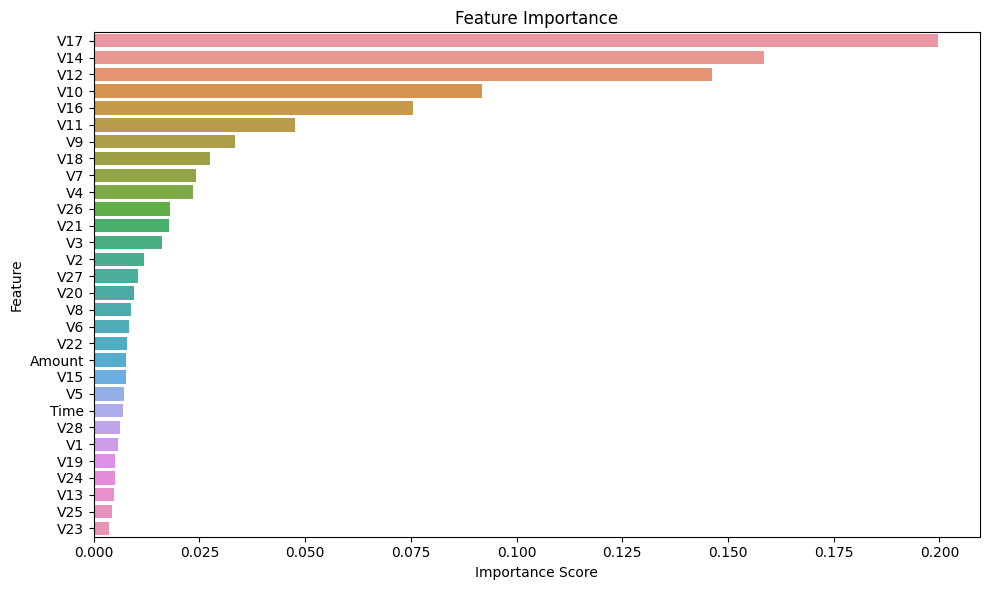

In [ ]:
plt.figure(figsize = (10, 6))
sns.barplot(data = feature_importance,
            x = 'Importance', 
            y = 'Feature')
plt.title('Feature Importance')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

LOGISTIC REGRESSION :-

In [73]:
model_logistic = LogisticRegression(class_weight= "balanced",
                                    max_iter = 1000,
                                    n_jobs = -1)
model_logistic.fit(x_train, y_train)

# class_weight = balanced ensures fraud instances have high penalty weight

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_log_prob = model_logistic.predict_proba(x_test)[:, 1]
y_log_pred = model_logistic.predict(x_test)

In [ ]:
print(classification_report(y_test, y_log_pred))
print(f"Logistic Regression AUPRC: {average_precision_score(y_test, y_log_prob):.4f}")